In [1]:
import glob

import cartopy.crs as ccrs
import cftime
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import om4labs.om4common as om4
import pandas as pd
import scipy.signal as signal
import xarray as xr
from eofs.xarray import Eof

# parameters for setting circular cutoff for Southern Ocean plots
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

out_path_fig = "/work/Katherine.Turner/smaller_projects/hifreq-variability/figures/"
out_path_data = "/work/Katherine.Turner/smaller_projects/hifreq-variability/data/"

In [2]:
mod = 'CM4'
ds_storms = xr.open_dataset(
    f"/work/Katherine.Turner/stormtrack_variability/data/{mod}_cmip_monthly_storms.nc",
    use_cftime=True,
)

ds_SAM_djf = xr.open_dataset(
    f"/work/Katherine.Turner/stormtrack_variability/data/{mod}_cmip_DJF_SAM.nc",
    use_cftime=True,
)

ds_SAM_jja = xr.open_dataset(
    f"/work/Katherine.Turner/stormtrack_variability/data/{mod}_cmip_JJA_SAM.nc",
    use_cftime=True,
)

In [3]:
storms_seasonal = ds_storms.center_counts.resample(time="QS-DEC").sum()[1:-1]
storms_djf = storms_seasonal[storms_seasonal.time.dt.month == 12]
storms_jja = storms_seasonal[storms_seasonal.time.dt.month == 6]

In [4]:
SAM_djf = ds_SAM_djf.pcs[ds_SAM_djf.time.dt.year.isin(storms_djf.time.dt.year)].squeeze()
SAM_jja = ds_SAM_jja.pcs[ds_SAM_jja.time.dt.year.isin(storms_jja.time.dt.year)].squeeze()

In [5]:
nSAM_djf = (SAM_djf - SAM_djf.mean()) / SAM_djf.std()
nSAM_jja = (SAM_jja - SAM_jja.mean()) / SAM_jja.std()

nSTV_djf = (storms_djf - storms_djf.mean())/storms_djf.std()
nSTV_jja = (storms_jja - storms_jja.mean())/storms_jja.std()

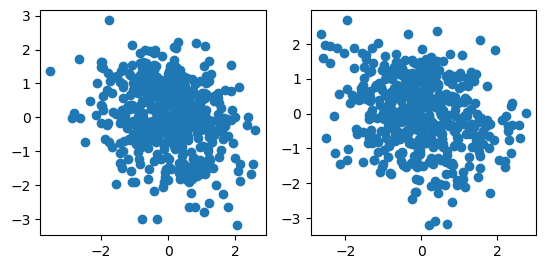

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=2)
axs[0].scatter(nSTV_djf, nSAM_djf)
axs[1].scatter(nSTV_jja, nSAM_jja)

for i in range(2):
    axs[i].set_box_aspect(1)

## multiple linear regression for some interior ventilation?

In [44]:
from sklearn.linear_model import LinearRegression

def ml_regress(b, A):
    """
    b: 1D numpy array with shape (time,)
    A: 2D numpy array with shape (time, 2) that contains normalized SAM and STV
    Returns:
      c_sam, c_stv, intercept
    """
    model = LinearRegression().fit(A, b)
    return np.array([model.coef_[0], model.coef_[1], model.intercept_])

def ml_regress_nd(field, X):
    
    field = field.fillna(0)
    
    betas = xr.apply_ufunc(
        ml_regress,
        field,     # y: 3D or 4D field
        X,         # X: 2D predictors
        input_core_dims=[["time"], ["time", "feature"]],
        output_core_dims=[["coeff"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        kwargs={}
    )
    
    #betas = betas.assign_coords(coeff=['c_sam', 'c_stv', 'intercept'])
    
    return betas

In [50]:
inputs_djf = xr.concat([nSAM_djf, nSTV_djf], dim='feature')
inputs_djf = inputs_djf.transpose("time", "feature")

inputs_jja = xr.concat([nSAM_jja, nSTV_jja], dim='feature')
inputs_jja = inputs_jja.transpose("time", "feature")

In [56]:
var_name = 'hfds'
ds_data = xr.open_mfdataset(f"/work/Katherine.Turner/tempest-extremes/{mod}_cmip/data/ocean_monthly_1x1deg*{var_name}*.nc")

da_data = (ds_data[var_name] - ds_data[var_name].mean(dim='time')).sel(lat=slice(-90,-30)).resample(time='QS-DEC').mean().compute()

data_djf = da_data[4:-1:4,:,:]
data_jja = da_data[2:-1:4,:,:]

In [57]:
test = ml_regress_nd(data_djf, inputs_djf)
test = ml_regress_nd(data_jja, inputs_jja)

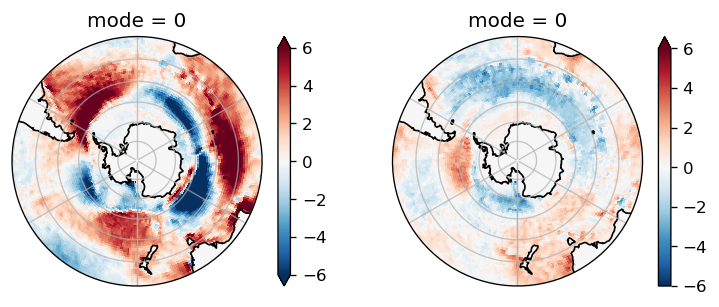

In [59]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(7.5, 2.7),
    dpi=120,
    subplot_kw={"projection": ccrs.SouthPolarStereo()},
)
test[:,:,0].plot(ax=axs[0],
                 x="lon", y="lat",
                 transform=ccrs.PlateCarree(),
                 vmin=-6, vmax=6,
                 cmap='RdBu_r',
                )

test[:,:,1].plot(ax=axs[1],
                 x="lon", y="lat",
                 transform=ccrs.PlateCarree(),
                 vmin=-6, vmax=6,
                 cmap='RdBu_r',
                )

for i in range(2):
    axs[i].set_ylabel("")
    axs[i].set_xlabel("")
    axs[i].set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
    axs[i].gridlines(alpha=0.7)
    axs[i].set_boundary(circle, transform=axs[i].transAxes)
    axs[i].coastlines()